
## 01MIAR - Actividad Video Valencia Pollution

## NumPy y Pandas

### Objetivos:
- Aplicar diferentes técnicas de tratamiento de estructuras numéricas con Numpy y datos estructurados con Pandas.

### Instrucciones:
- Mantener una estructura limpia, comentando código y secuenciando los apartados con el código correspondiente que resuelva la actividad.
- Como criterio de evaluación se tendrá en cuenta el resultado, la consecución del mismo, estilo, comentarios y adecuación. Siempre será tenido en cuenta cualquier detalle técnico avanzado o no visto en clase relacionado con el tema (explicar el porqué y usabilidad).
- No está permitido compartir los resultados ni el código en ninguno de los foros.
- Revisar los temas así como las sesiones sobre Numpy y Pandas para aplicar dichos contenidos.
- Proponer las respuestas en las celdas a dicho efecto en cada punto, si se necesitan más celdas añadirlas en su sitio correspondiente
- Mostrar de manera clara la respuesta a las preguntas, mediante código

### Entrega:
- Este mismo notebook con las respuetas

### Evaluación
- Esta actividad corresponde con el 10% de la nota final de la asignatura.

### Fecha Realización
- Convocatoria 1 - 30/05/2026 00:00 - 31/05/2026 08:00 (Hora España)

#### Descripción
El conjunto de datos "valencia_pollution_dataset.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web del ayuntamiento de la ciudad de Valencia de datos abiertos.

Cada estación realiza una serie de mediciones acerca de la calidad del aire, y de ciertas sustancias que se consideran importantes para analizar la contaminación atmosférica en la ciudad.

#### Columnas para trabajar:
- objectid: id de la estación
- nombre: nombre de la estación
- dirección: dirección de la estación
- tipozona: tipo de la zona, urbana o sub urbana
- parámetros: parámetroe medidos
- mediciones: fichero de mediciones
- tipoemisio: tráfico o fondo
- so2: niveles de dióxido de azufre
- no2: niveles de dióxido de nitrogeno
- o3: niveles de ozono
- co: niveles de monóxido de carbono
- pm10: niveles de partículas en suspensión hasta 10um
- pm25: niveles de partículas en suspensión hasta 2,5um
- fecha_carg: timestamp de la actualización de los datos
- calidad_am: estimación de la calidad del aire
- fiwareid: Identificador sensor
- lon: longitud en coordenadas geográficas
- lat: latitud en coordenadas geográficas

In [1]:
# Your imports here...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 01
- Carga de datos de csv (valencia_pollution_dataset.csv) en un DataFrame.
- Mostrar 6 fillas aleatorias
- Mostrar la cantidad de valores nulos por columna

In [2]:
# Your solution here...
ruta = os.path.join("." ,"valencia_pollution_dataset.csv")
df = pd.read_csv(ruta, sep=',', na_values='')

print("Ejemplo de filas:")
display(df.sample(6))

total_nulos = df.isnull().sum()
total_nulos.name = "Valores nulos por columna:"
print()
print(total_nulos)

Ejemplo de filas:


,objectid,nombre,direccion,tipozona,parametros,mediciones,so2,no2,o3,co,pm10,pm25,tipoemisio,fecha_carg,calidad_am,fiwareid,lon,lat
87,19,Centro,VALÈNCIA CENTRE,Urbana,"Óxidos de nitrógeno totales (NOx),Monóxido de ...",https://mapas.valencia.es/WebsMunicipales/uplo...,NaN,22.0,NaN,NaN,27.0,10.0,Tráfico,2026-05-28 05:00:00,Razonablemente Buena,A07_VALENCIACENTRE_60m,-0.376398,39.470548
109,15,Molí del Sol,MOLÍ DEL SOL,Suburbana,"Dióxido de azufre (SO2),Monóxido de carbono (C...",http://mapas.valencia.es/WebsMunicipales/uploa...,9.0,36.0,39.0,0.0,22.0,10.0,Tráfico,2026-05-28 06:00:00,Razonablemente Buena,A03_MOLISOL_60m,-0.408810,39.481112
136,13,Francia,AVDA.FRANCIA,Urbana,"Dióxido de azufre (SO2),Monóxido de carbono (C...",http://mapas.valencia.es/WebsMunicipales/uploa...,2.0,30.0,52.0,0.0,31.0,8.0,Tráfico,2026-05-28 09:00:00,Razonablemente Buena,A01_AVFRANCIA_60m,-0.342986,39.457827
166,20,Cabanyal,CABANYAL,Urbana,NaN,NaN,NaN,48.0,NaN,NaN,30.0,12.0,Fondo,2026-05-28 12:00:00,Razonablemente Buena,A09_CABANYAL_60m,-0.328535,39.474391
259,15,Molí del Sol,MOLÍ DEL SOL,Suburbana,"Dióxido de azufre (SO2),Monóxido de carbono (C...",http://mapas.valencia.es/WebsMunicipales/uploa...,5.0,14.0,56.0,0.0,25.0,10.0,Tráfico,2026-05-29 01:00:00,Razonablemente Buena,A03_MOLISOL_60m,-0.408810,39.481112
32,19,Centro,VALÈNCIA CENTRE,Urbana,"Óxidos de nitrógeno totales (NOx),Monóxido de ...",https://mapas.valencia.es/WebsMunicipales/uplo...,NaN,12.0,NaN,NaN,27.0,11.0,Tráfico,2026-05-28,Razonablemente Buena,A07_VALENCIACENTRE_60m,-0.376398,39.470548



objectid        0
nombre          0
direccion       0
tipozona        0
parametros     26
mediciones    104
so2           130
no2             0
o3            130
co            208
pm10           52
pm25           52
tipoemisio      0
fecha_carg      0
calidad_am      0
fiwareid        0
lon             0
lat             0
Name: Valores nulos por columna:, dtype: int64


## 02
- ¿Cuantas estaciones diferentes hay?
- ¿Cuantas estaciones cuentan con un sensor de monóxido de carbono (co)?
- ¿Cuantas estaciones cuentan con un sensor ozono (o3)?

In [3]:
# Your solution here...
def estaciones_con_sensor(df, sensor_col):
    mask_not_null = ~(df[sensor_col].isnull())
    df_not_null = df[mask_not_null]
    estaciones_not_null = df_not_null["nombre"].nunique()
    return estaciones_not_null

n_estaciones = df["nombre"].nunique()
print(f"Hay {n_estaciones} estaciones diferentes")
print(f"Hay {estaciones_con_sensor(df, "co")} estación(es) con un sensor de monóxido de carbono")
print(f"Hay {estaciones_con_sensor(df, "o3")} estación(es) con un sensor de ozono")

Hay 11 estaciones diferentes
Hay 3 estación(es) con un sensor de monóxido de carbono
Hay 6 estación(es) con un sensor de ozono


## 03
 - Para cada sensor (co, o3, no2, so2, pm10 y pm25) indicar la estación con la media de medición más alta.

In [4]:
# Your solution here...
sensores = ["co", "o3", "no2", "so2", "pm10", "pm25"]
media_por_estacion = df[ ["nombre"] + sensores ].groupby("nombre").mean()

for sensor_col in sensores:
    maxmedia_estacion = media_por_estacion[sensor_col].idxmax()
    maxmedia_val = media_por_estacion[sensor_col][maxmedia_estacion]
    print(f"La media mas alta para el sensor {sensor_col} se obtuvo en la estación {maxmedia_estacion}.")
    print(f"\t{sensor_col} = {maxmedia_val}")

La media mas alta para el sensor co se obtuvo en la estación Francia.
	co = 0.0
La media mas alta para el sensor o3 se obtuvo en la estación Viveros.
	o3 = 78.92307692307692
La media mas alta para el sensor no2 se obtuvo en la estación Patraix.
	no2 = 53.0
La media mas alta para el sensor so2 se obtuvo en la estación Molí del Sol.
	so2 = 6.115384615384615
La media mas alta para el sensor pm10 se obtuvo en la estación Olivereta.
	pm10 = 33.76923076923077
La media mas alta para el sensor pm25 se obtuvo en la estación Olivereta.
	pm25 = 15.0


## 04
Mostrar en dos gráficos de barras la media de las mediciones de dióxido de nitrógeno (no2) de cada estación agrupando por el tipo de zona (tipozona). Cada gráfico debe mostrar un tipo de emisión distinto (tipoemision).

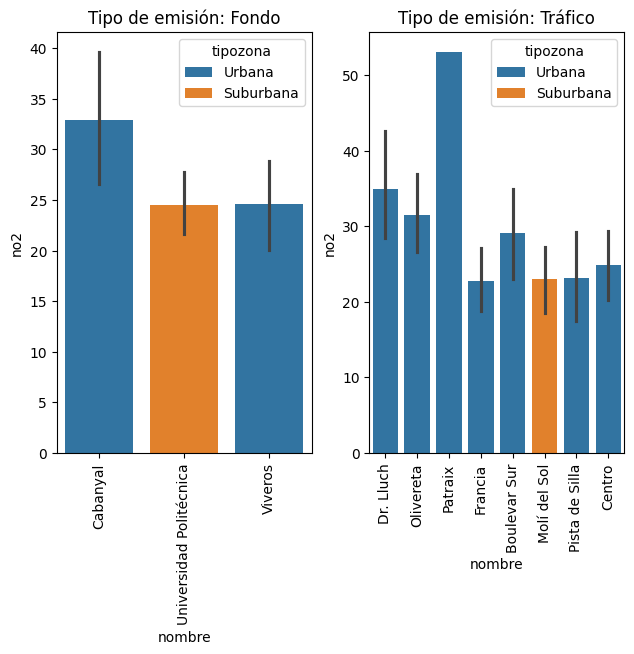

In [5]:
# Your solution here...
agrupar_tipoemision = df.groupby("tipoemisio")
num_subplots = df["tipoemisio"].nunique()
fig, axes = plt.subplots(1,  num_subplots)
fig.tight_layout()

for iax, grupo in enumerate(agrupar_tipoemision):
    tipo_emision, df_vista = grupo
    sns.barplot(x='nombre', y='no2', hue='tipozona', data=df_vista, ax=axes[iax])
    axes[iax].set_title(f"Tipo de emisión: {tipo_emision}")
    axes[iax].tick_params("x", rotation=90)

## 05
Eres un analista de datos y quieres evaluar visualmente si existe una relación entre las mediciones de los sensores (co, o3, no2, so2, pm10 y pm25) y la calidad del aire (calidad_ambiental). ¿Qué visualización propones y porqué?

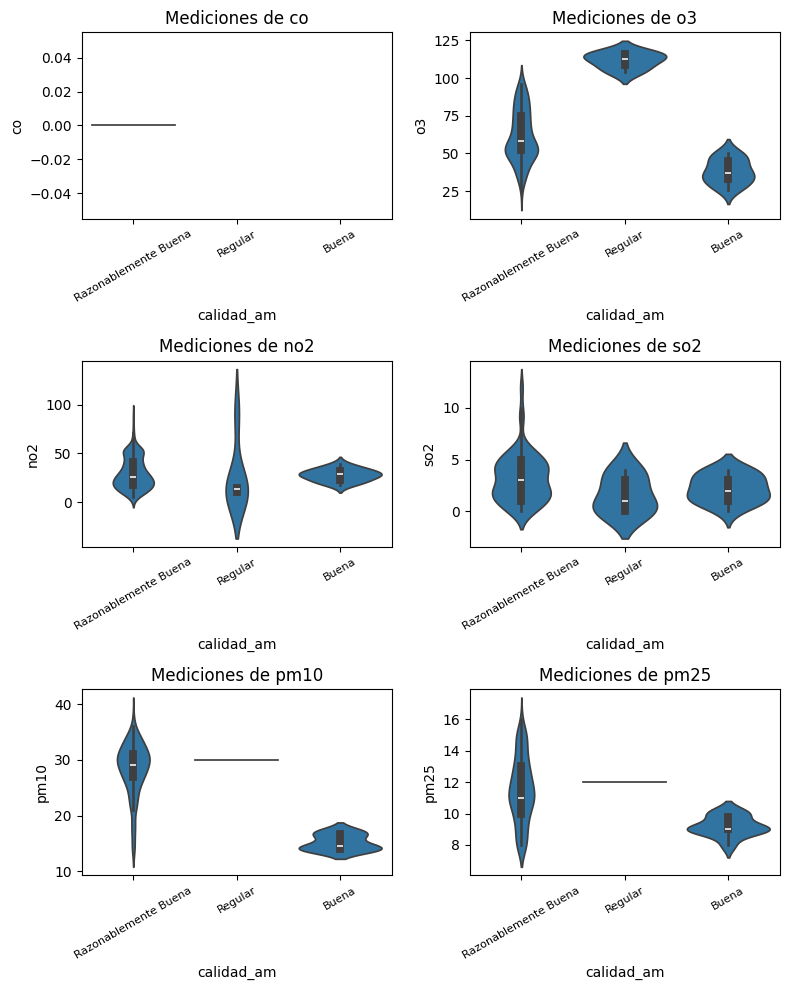

In [6]:
# Your proposal here...
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

for iax, sensor_col in enumerate(sensores):
    axis = axes[iax//2][iax%2]
    data_calidad_sensor = df[[sensor_col, "calidad_am"]]
    sns.violinplot(data=data_calidad_sensor, x="calidad_am", y=sensor_col, ax=axis)
    axis.set_title(f"Mediciones de {sensor_col}")
    axis.tick_params("x", rotation=30, labelsize=8)

fig.tight_layout()
plt.show()

#### Razonamiento

Se propone utilizar gráficas de violín ya que este tipo de visualizaciones nos prmite observar distribuciones de variables que no sabemos si presentarán una distribución Gaussiana. Además, podemos verificar si dicha distribución de las mediciones varía según la calidad del aire. Se coloca cada sensor en su propio subplot porque los rangos de medición de cada sensor puede ser diferente, por lo tanto, en cada subplot visualizamos desviaciones relativas entre diferentes calidades de aire.